In [309]:
import pandas as pd
import nltk
import re
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Preprocessing

#### Merge all text columns into one

In [310]:
def merge_cols(row, columns):
    merged = ''
    is_na = row.isna()
    for col in columns:
        if not is_na[col]:
            merged = merged + row[col] + ' '
    merged = merged[:-1]
    return merged

In [311]:
def merge_all(df=None, in_file=None, out_file=None):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file, encoding = 'ISO-8859-1')
    text_cols = df.columns[1:]
    out_df = pd.DataFrame(df.iloc[:, 0].values, columns=['class'])
    out_df['body'] = df.apply(lambda row: merge_cols(row, text_cols), axis='columns')
    if out_file is not None:
        out_df.to_csv(out_file, index=False)
    return out_df

In [312]:
_ = merge_all(in_file='data/spam.csv', out_file='data/mergedSpam.csv')

### Get Frequencies

In [313]:
def tokenize(text):
    # Remove single periods, commas, apostrophes, quotes, and parentheses
    text = re.sub(r'(?<!\.)\.(?!\.)|,|\'|\"|\(|\)|‘|’|“|”', '', text)
    
    # Use nltk to split into tokens
    tokens = nltk.word_tokenize(text)
    
    # I'm leaving other punctuation since it can be an indicator of being spam, such as many exclamation marks, etc.
    # nltk tokenize should mostly split those punctuations into their own tokens
    return tokens

In [314]:
def vectorize(df=None, in_file=None, out_file=None, vectorizer_func=CountVectorizer):
    """
    Expects a dataframe that has been merged. This should only be called on training set
    Use vectorizer_transform_df after to vectorize testing set. (This doesnt really matter for wordcount but does for tfidf)
    :param df: 
    :param in_file: 
    :param out_file: 
    :param vectorizer_func: 
    :return: 
    """
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file, encoding = 'ISO-8859-1')
    vectorizer = vectorizer_func(tokenizer=tokenize, token_pattern=None, stop_words='english')
    vectors = vectorizer.fit_transform(df['body'])
    out_df = pd.DataFrame.sparse.from_spmatrix(vectors, columns=vectorizer.get_feature_names_out())
    # Since class could be a word, I am using .class.
    df.reset_index(drop=True, inplace=True)
    out_df['.class.'] = df['class']
    if out_file is not None:
        out_df.to_csv(out_file, index=False)
    return out_df, vectorizer

In [315]:
def vectorizer_transform_df(vectorizer, df=None, in_file=None, out_file=None):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file, encoding = 'ISO-8859-1')
    vectors = vectorizer.transform(df['body'])
    out_df = pd.DataFrame.sparse.from_spmatrix(vectors, columns=vectorizer.get_feature_names_out())
    df.reset_index(drop=True, inplace=True)
    out_df['.class.'] = df['class']
    if out_file is not None:
        out_df.to_csv(out_file, index=False)
    return out_df

# Multinomial NB

In [316]:
def train(df=None, in_file=None, classifier=MultinomialNB, **kwargs):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    clf = classifier(**kwargs)
    clf.fit(df.drop(columns=['.class.']), df['.class.'])
    return clf

In [317]:
def test(df=None, in_file=None, vectorizer_func=CountVectorizer, frac=0.2, classifier=MultinomialNB, **kwargs):
    """
    Expects a dataframe that has been merged but not vectorized
    :param df: 
    :param in_file: 
    :param vectorizer_fun: 
    :param frac: 
    :param classifier: 
    :param kwargs: 
    :return: 
    """
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    train_df, test_df = train_test_split(df, train_size=frac)
    train_df, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
    #train_df = smote.fit_resample(train_df)
    #display(train_df)
    test_df = vectorizer_transform_df(vectorizer, test_df)
    clf = train(df=train_df, classifier=classifier, **kwargs)
    training_accuracy = clf.score(train_df.drop(columns=['.class.']), train_df['.class.'])
    testing_accuracy = clf.score(test_df.drop(columns=['.class.']), test_df['.class.'])
    print(f'Overall Accuracy')
    print(f'Training Accuracy: {training_accuracy:.2f}')
    print(f'Testing Accuracy: {testing_accuracy:.2f}')
    train_proportions = train_df['.class.'].value_counts(normalize=True)
    test_proportions = test_df['.class.'].value_counts(normalize=True)
    class_labels = ['ham', 'spam']
    for label in class_labels:
        label_train_df = train_df.loc[train_df['.class.'] == label]
        label_test_df = test_df.loc[test_df['.class.'] == label]
        label_train_accuracy = clf.score(label_train_df.drop(columns=['.class.']), label_train_df['.class.'])
        label_test_accuracy = clf.score(label_test_df.drop(columns=['.class.']), label_test_df['.class.'])
        print(f'{label} Stats:')
        print(f'Proportion of Training Set: {train_proportions[label]:.2f}')
        print(f'Training Accuracy: {label_train_accuracy:.2f}')
        print(f'Proportion of Test Set: {test_proportions[label]:.2f}')
        print(f'Testing Accuracy: {label_test_accuracy:.2f}')

In [318]:
print('Word Counts')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=CountVectorizer)
print('---------')
print('TFIDF')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=TfidfVectorizer)

Word Counts
Overall Accuracy
Training Accuracy: 1.00
Testing Accuracy: 0.98
ham Stats:
Proportion of Training Set: 0.87
Training Accuracy: 1.00
Proportion of Test Set: 0.87
Testing Accuracy: 1.00
spam Stats:
Proportion of Training Set: 0.13
Training Accuracy: 0.98
Proportion of Test Set: 0.13
Testing Accuracy: 0.88
---------
TFIDF
Overall Accuracy
Training Accuracy: 0.96
Testing Accuracy: 0.93
ham Stats:
Proportion of Training Set: 0.84
Training Accuracy: 1.00
Proportion of Test Set: 0.87
Testing Accuracy: 1.00
spam Stats:
Proportion of Training Set: 0.16
Training Accuracy: 0.75
Proportion of Test Set: 0.13
Testing Accuracy: 0.49


## KNN

In [326]:
print('Word Counts')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=CountVectorizer, classifier=KNeighborsClassifier, n_neighbors=3)
print('---------')
print('TFIDF')
_ = test(in_file='data/mergedSpam.csv', vectorizer_func=TfidfVectorizer, classifier=KNeighborsClassifier, n_neighbors=3)

Word Counts
Overall Accuracy
Training Accuracy: 0.90
Testing Accuracy: 0.89
ham Stats:
Proportion of Training Set: 0.86
Training Accuracy: 1.00
Proportion of Test Set: 0.87
Testing Accuracy: 1.00
spam Stats:
Proportion of Training Set: 0.14
Training Accuracy: 0.30
Proportion of Test Set: 0.13
Testing Accuracy: 0.15
---------
TFIDF
Overall Accuracy
Training Accuracy: 0.96
Testing Accuracy: 0.95
ham Stats:
Proportion of Training Set: 0.87
Training Accuracy: 1.00
Proportion of Test Set: 0.87
Testing Accuracy: 1.00
spam Stats:
Proportion of Training Set: 0.13
Training Accuracy: 0.75
Proportion of Test Set: 0.13
Testing Accuracy: 0.68


In [320]:
def knn_cross_validation(df=None, in_file=None, k=10, K_arr = (1, 3, 5, 7, 10, 15, 20), vectorizer_func=CountVectorizer, **kwargs):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    avg_accuracy = {cl: [0] * len(K_arr) for cl in ('Total', 'ham', 'spam')}
    std_error = {cl: [0] * len(K_arr) for cl in ('Total', 'ham', 'spam')}
    num_per_split = df.shape[0] // k
    for i, m in enumerate(K_arr):
        accuracy = {cl: [0] * k for cl in ('Total', 'ham', 'spam')}
        for idx in range(k):
            train_df = df.iloc[(num_per_split * idx):(num_per_split * (idx + 1))]
            train_set, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
            test_df = df.drop(train_set.index)
            test_set = vectorizer_transform_df(vectorizer, test_df)
            clf = train(df=train_set, classifier=KNeighborsClassifier, n_neighbors=m, **kwargs)
            accuracy['Total'][idx] = clf.score(test_set.drop(columns=['.class.']), test_set['.class.'])
            grouped = test_set.groupby('.class.')
            for cl, group in grouped:
                accuracy[cl][idx] = clf.score(group.drop(columns=['.class.']), group['.class.'])
        for cl in ('Total', 'ham', 'spam'):
            avg_accuracy[cl][i] = np.sum(accuracy[cl]) / k
            std_error[cl][i] = np.std(accuracy[cl]) / np.sqrt(k)
            #print(f'{m} Nearest Neighbors: {cl} - {avg_accuracy[cl][i]:.2f}')
    return avg_accuracy, std_error

In [321]:
def plot_knn_cross_validate():
    avg_accuracy = {}
    std_error = {}
    K_arr = (1, 3, 5, 7, 10, 15, 20)
    avg_accuracy['Word Count'], std_error['Word Count'] = knn_cross_validation(in_file='data/mergedSpam.csv', vectorizer_func=CountVectorizer, weights='distance')
    avg_accuracy['TF-IDF'], std_error['TF-IDF'] = knn_cross_validation(in_file='data/mergedSpam.csv', vectorizer_func=TfidfVectorizer, weights='distance')
    fig, ax = plt.subplots(2, 1)
    for i, vec in enumerate(('Word Count', 'TF-IDF')):
        for cl in ('Total', 'ham', 'spam'):
            ax[i].errorbar(K_arr, avg_accuracy[vec][cl], yerr=std_error[vec][cl], label=cl)
        ax[i].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax[i].set_xticks(range(21))
        ax[i].set_title(vec)
        ax[i].set_xlabel('k')
        ax[i].set_ylabel('Accuracy')
        ax[i].legend()
    fig.tight_layout()
    plt.show()
    return avg_accuracy, std_error

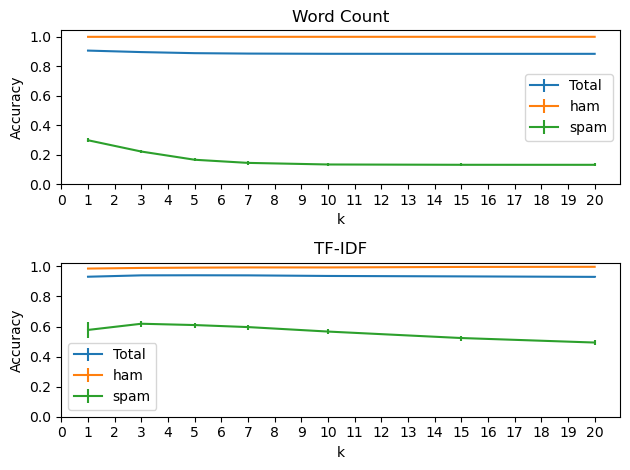

In [322]:
knn_cross_results = plot_knn_cross_validate()

## Cross Validation


In [323]:
def incremental_cross_validation(df=None, in_file=None, k=10, frac_arr = (0.025, 0.05, 0.075, 0.1, 0.15, 0.2), vectorizer_func=CountVectorizer, classifier=KNeighborsClassifier, **kwargs):
    if df is None:
        if in_file is None:
            return
        df = pd.read_csv(in_file)
    avg_accuracy = {cl: [0] * len(frac_arr) for cl in ('Total', 'ham', 'spam')}
    std_error = {cl: [0] * len(frac_arr) for cl in ('Total', 'ham', 'spam')}
    num_per_split = df.shape[0] // k
    shuffled_df = df.sample(frac=1)
    for i, frac in enumerate(frac_arr):
        accuracy = {cl: [0] * k for cl in ('Total', 'ham', 'spam')}
        for idx in range(k):
            test_df = shuffled_df.iloc[(num_per_split * idx):(num_per_split * (idx + 1))]
            train_df = shuffled_df.drop(test_df.index)
            train_df = train_df.sample(frac=frac)
            train_set, vectorizer = vectorize(train_df, vectorizer_func=vectorizer_func)
            test_set = vectorizer_transform_df(vectorizer, test_df)
            clf = train(df=train_set, classifier=classifier, **kwargs)
            accuracy['Total'][idx] = clf.score(test_set.drop(columns=['.class.']), test_set['.class.'])
            grouped = test_set.groupby('.class.')
            for cl, group in grouped:
                accuracy[cl][idx] = clf.score(group.drop(columns=['.class.']), group['.class.'])
        for cl in ('Total', 'ham', 'spam'):
            avg_accuracy[cl][i] = np.sum(accuracy[cl]) / k
            std_error[cl][i] = np.std(accuracy[cl]) / np.sqrt(k)
    return avg_accuracy, std_error

In [331]:
def plot_incremental_cross_validate():
    avg_accuracy = {}
    std_error = {}
    frac_arr = np.array([0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5])
    k = 10
    fig, ax = plt.subplots(2, 2)
    df = pd.read_csv('data/mergedSpam.csv')
    for j, classifier in enumerate(('Multinomial Naive Bayes', '3-Nearest-Neighbors')):
        avg_accuracy[classifier] = {}
        std_error[classifier] = {}
        for i, vec in enumerate(('Word Count', 'TF-IDF')):
            vectorizer_func = CountVectorizer
            if vec == 'TF-IDF':
                vectorizer_func = TfidfVectorizer
            kwargs = {}
            classifier_func = MultinomialNB
            if classifier == '3-Nearest-Neighbors':
                classifier_func = KNeighborsClassifier
                kwargs['n_neighbors'] = 3
            avg_accuracy[classifier][vec], std_error[classifier][vec] = incremental_cross_validation(df=df, vectorizer_func=vectorizer_func, classifier=classifier_func, frac_arr=frac_arr, **kwargs) 
            for cl in ('Total', 'ham', 'spam'):
                ax[i][j].errorbar(frac_arr * df.shape[0] // k * 9, avg_accuracy[classifier][vec][cl], yerr=std_error[classifier][vec][cl], label=cl)
            ax[i][j].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
            #ax[i][j].set_xticks(np.arange(0, 0.425, 0.025))
            ax[i][j].set_title(f'{classifier} {vec}')
            ax[i][j].set_xlabel('Number of Samples')
            ax[i][j].set_ylabel('Accuracy')
            ax[i][j].legend()
    fig.tight_layout()
    plt.show()
    return avg_accuracy, std_error

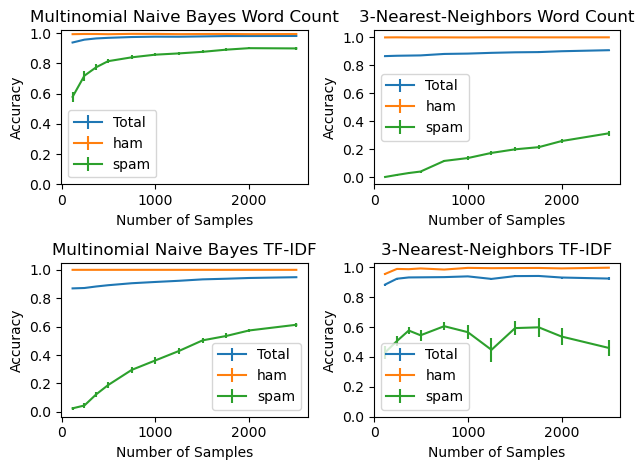

In [332]:
incremental_results = plot_incremental_cross_validate()